# Nueral Network Classification with TensorFlow

Few types of classification:
- Binary classification
- Multiclass classification
- Multilabel classification

## Creating data to view and fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000
n_samples = 1000

# Create circles
X, y = make_circles(n_samples=n_samples, random_state=42, noise=0.03)
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

#### Visualize the data

In [2]:
import pandas as pd

circles = pd.DataFrame({'X0':X[:,0],
                        'X1':X[:,1],
                        'y':y})

circles.head()

,X0,X1,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


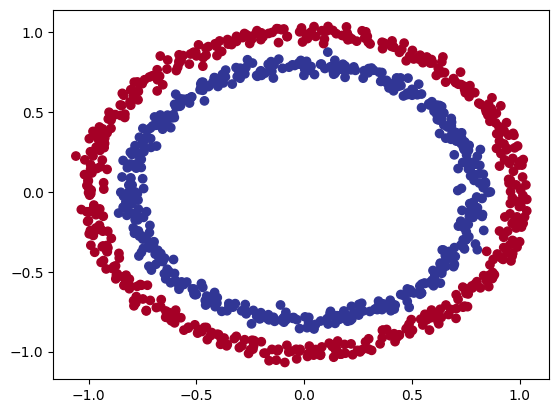

In [3]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

## Input and Output shapes

In [4]:
# Check the shapes of features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [5]:
# Example of feature and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in modeliing

Thes steps in modelling in TensorFlow are typically:

1. Create model
2. Compile model
3. Fit the model
4. Evaluate model
5. Tweak and evaluate

In [6]:
import tensorflow as tf

# Set seed
tf.random.set_seed(42)

# Create model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Model compilation
model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['accuracy','precision','recall']
)

# Model Fitting
model_1.fit(X,y,epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4940 - loss: 1.0678 - precision: 0.4908 - recall: 0.3200
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4890 - loss: 0.7095 - precision: 0.4873 - recall: 0.4220
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4960 - loss: 0.6996 - precision: 0.4958 - recall: 0.4700
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4910 - loss: 0.6964 - precision: 0.4908 - recall: 0.4780
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4840 - loss: 0.6952 - precision: 0.4839 - recall: 0.4820


In [7]:
# Training for longer
model_1.fit(X,y,epochs=200,verbose=0)
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4730 - loss: 0.6933 - precision: 0.4526 - recall: 0.2580  


[0.6932879686355591, 0.4729999899864197, 0.4526315927505493, 0.257999986410141]

Model is only 50% accuracy -> More layers

In [8]:
# set the random seed
tf.random.set_seed(42)

# Create a model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
])

# Compile the model
model_2.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['accuracy']
)

# fit model
model_2.fit(X,y,epochs=100, verbose=0)

In [9]:
model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 0.6932  


[0.6932412981987, 0.47699999809265137]

### Improving the model

1. Create a model - add more layers, increase nuerons per layer
2. Compile the model - add activation, optimizer
3. Fit the model - run for longer

In [10]:
#Set the seed
tf.random.set_seed(42)

# create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compile the model
model_3.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# fit the model
model_3.fit(X,y,epochs=100, verbose=False)

In [11]:
# evaluate
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 0.6947  


[0.6946547627449036, 0.4860000014305115]

### Visualization function

In [12]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots decision boundary created by model, predicting on X
  """
  # Define the axis boundaries of the plot and create a meshgrid
  X_min, X_max = X[:, 0].min() - 0.1, X[:,1].max() + 0.1
  y_min, y_max = X[:, 0].min() - 0.1, X[:,1].max() + 0.1

  xx, yy = np.meshgrid(np.linspace(X_min, X_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X value (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrasy together

  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print('Multi-Class classification')
    # We have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print('Binary Classification')
    y_pred = np.round(y_pred).reshape(xx.shape)


  # Plot the decisoin boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


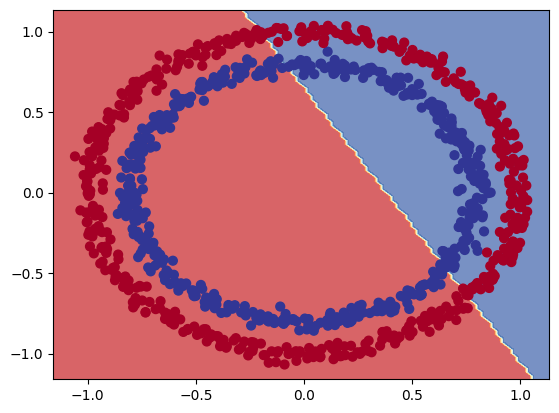

In [13]:
# Check the predictions the model is making
plot_decision_boundary(model_3, X, y)

## Trying use the same model for regerssion problem to see if the linear boundary is useful

In [14]:
from sklearn.model_selection import train_test_split

# Data generation
tf.random.set_seed(42)

X_reg = tf.range(0, 1000, 5).numpy()
y_reg = tf.range(100, 1100, 5).numpy() # y = X+100

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.15, random_state=42)
len(X_reg_train), len(y_reg_test)

(170, 30)

In [15]:
# Fit the current model to regression data
model_3.fit(tf.expand_dims(X_reg_train,1), y_reg_train, epochs=100, verbose=0)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_3' is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (None, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

## We need a regression based loss function, currently using Binary Cross Entropy


In [16]:

# set seed
tf.random.set_seed(42)

# create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

# compile the model
model_3.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics=['mae','mse']
)

# fit the model
model_3.fit(tf.expand_dims(X_reg_train,1), y_reg_train, epochs=100, verbose=0)

In [17]:
# evaluate the model
model_3.evaluate(X_reg_test, y_reg_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 35.1351 - mae: 35.1351 - mse: 1830.7036


[35.13508987426758, 35.13508987426758, 1830.70361328125]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


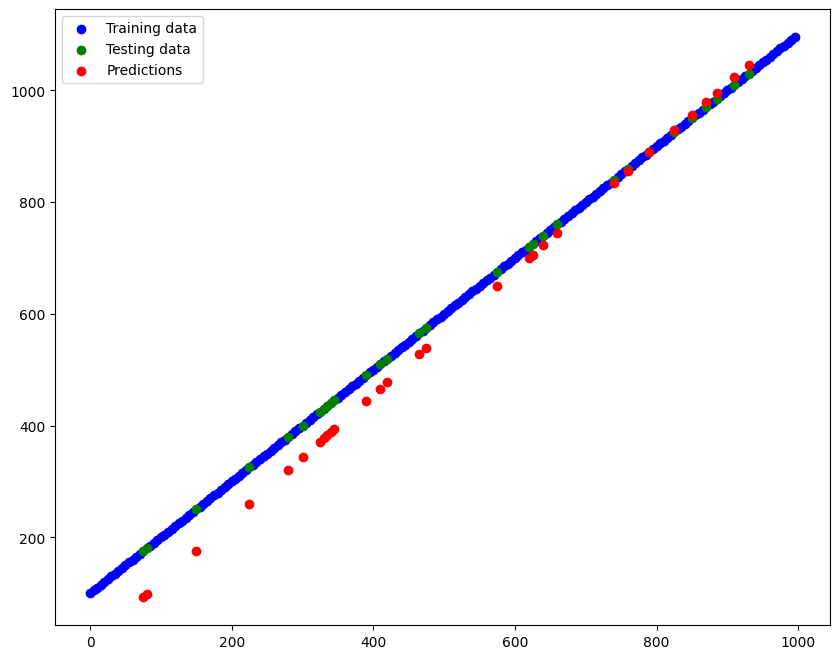

In [18]:
# Make predicitons with the train model
y_reg_preds =  model_3.predict(X_reg_test)

# Plot the models predcitions
plt.figure(figsize=(10,8))
plt.scatter(X_reg_train, y_reg_train, c='b', label='Training data')
plt.scatter(X_reg_test, y_reg_test, c='g', label='Testing data')
plt.scatter(X_reg_test, y_reg_preds, c='r', label='Predictions')
plt.legend()

## The missing piece: Non linearity

In [19]:
# New model with linear activation
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='linear'),
    tf.keras.layers.Dense(10, activation='linear'),
    tf.keras.layers.Dense(1, activation='linear'),
])

model_4.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy', 'recall']
)

history = model_4.fit(X, y, epochs=100, verbose=False)

In [20]:
# Relu activation
tf.random.set_seed(42)

model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='relu')
])

model_5.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4850 - loss: 5.8142
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 5.7771
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4770 - loss: 5.7196
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 5.6522
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 5.6412
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4760 - loss: 5.6252
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 5.5787
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4790 - loss: 5.4629
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 5.3422
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 5.1960
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.9788
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [21]:
# recreate multi layer NN

tf.random.set_seed(42)

model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu'),
])

model_6.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

model_6.fit(X,y, epochs=300)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4730 - loss: 2.7642
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4670 - loss: 2.5629
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4720 - loss: 2.3331
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4700 - loss: 2.0217
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4670 - loss: 1.2416
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4480 - loss: 0.9354
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3930 - loss: 0.8993
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3560 - loss: 0.8814
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3310 - loss: 0.8689
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3370 - loss: 0.8589
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3280 - loss: 0.8505
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [22]:
model_6.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9740 - loss: 0.1864  


[0.18636201322078705, 0.9739999771118164]

In [23]:
# Model the circle with correct sigmoid activation for the final dense layer

tf.random.set_seed(42)

model_7 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid'),
])

model_7.compile(
    loss = 'binary_crossentropy',
    optimizer = 'Adam',
    metrics = ['accuracy']
)

model_7.fit(X,y,epochs=200, verbose=0)

In [24]:
model_7.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9920 - loss: 0.1425  


[0.14248880743980408, 0.9919999837875366]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


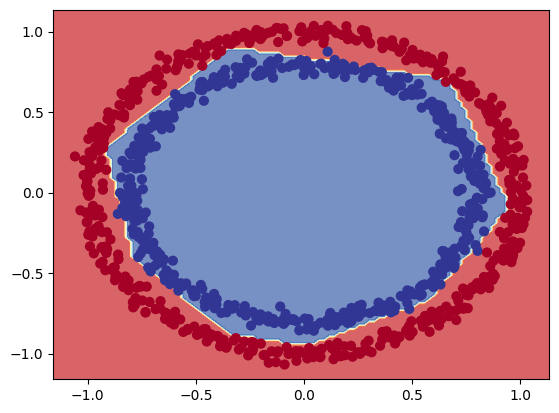

In [25]:
plot_decision_boundary(model_7, X, y)

## Evaluating and improving the classfication model

In [26]:
# Check how many examples we have
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
len(X_train), len(y_test)

(800, 200)

In [27]:
X_train.shape, y_test.shape

((800, 2), (200,))

In [28]:
# Final model for evaluation
tf.random.set_seed(42)

model_8 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model_8.compile(
    loss = 'binary_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

history = model_8.fit(X_train, y_train, epochs=50, verbose=0)

model_8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0236  


[0.023561131209135056, 1.0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


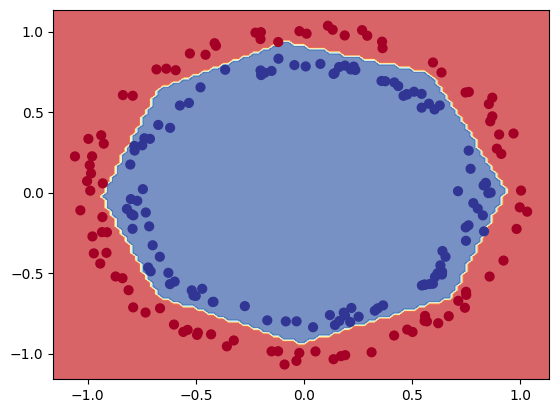

In [29]:

plot_decision_boundary(model_8, X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


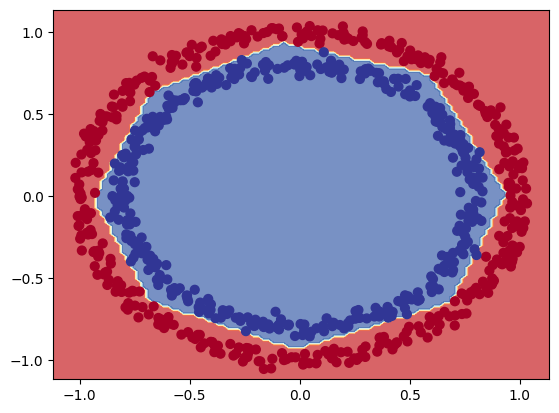

In [30]:
plot_decision_boundary(model_8, X_train, y_train)

## Plot loss curves

In [31]:
history.history

{'accuracy': [0.4925000071525574,
  0.5212500095367432,
  0.5512499809265137,
  0.5950000286102295,
  0.6274999976158142,
  0.6675000190734863,
  0.6862499713897705,
  0.7074999809265137,
  0.7137500047683716,
  0.7487499713897705,
  0.7962499856948853,
  0.8424999713897705,
  0.9212499856948853,
  0.9775000214576721,
  0.9887499809265137,
  0.9900000095367432,
  0.9912499785423279,
  0.9925000071525574,
  0.9912499785423279,
  0.9937499761581421,
  0.9950000047683716,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9975000023841858,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563,
  0.9962499737739563

In [32]:
# Convert into a dataframe
pd.DataFrame(history.history)

,accuracy,loss
0,0.49250,0.688129
1,0.52125,0.679840
2,0.55125,0.675389
3,0.59500,0.668439
4,0.62750,0.659985
5,0.66750,0.647461
6,0.68625,0.629727
7,0.70750,0.607755
8,0.71375,0.580734
9,0.74875,0.547709


Text(0.5, 1.0, 'Loss curves')

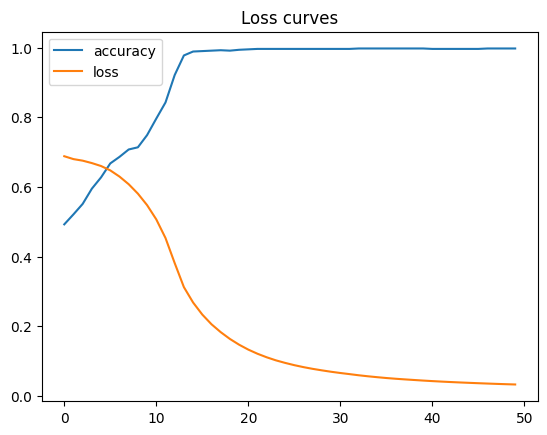

In [33]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title('Loss curves')

 ## Finding hte ideal learning rate

 The loss which causes the loss decrease during training:
 - Learning Rate Callback

In [34]:
tf.random.set_seed(42)

model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model_9.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# Fit the model
history_9 = model_9.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4837 - loss: 0.7639 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4888 - loss: 0.7616 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4837 - loss: 0.7591 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4775 - loss: 0.7564 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4750 - loss: 0.7535 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4863 - loss: 0.7505 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4850 - loss: 0.7473 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4875 - loss: 0.7440 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4825 - loss: 0.7405 - learning_

<Axes: xlabel='epochs'>

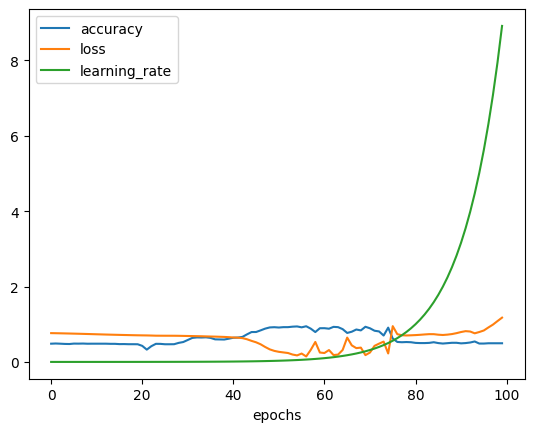

In [35]:
# check history
pd.DataFrame(history_9.history).plot(xlabel='epochs')

In [36]:
# plot only the lr and the loss

lrs = 1e-4 * (10 ** (tf.range(100)/20))

Text(0.5, 1.0, 'Learning rate vs. loss')

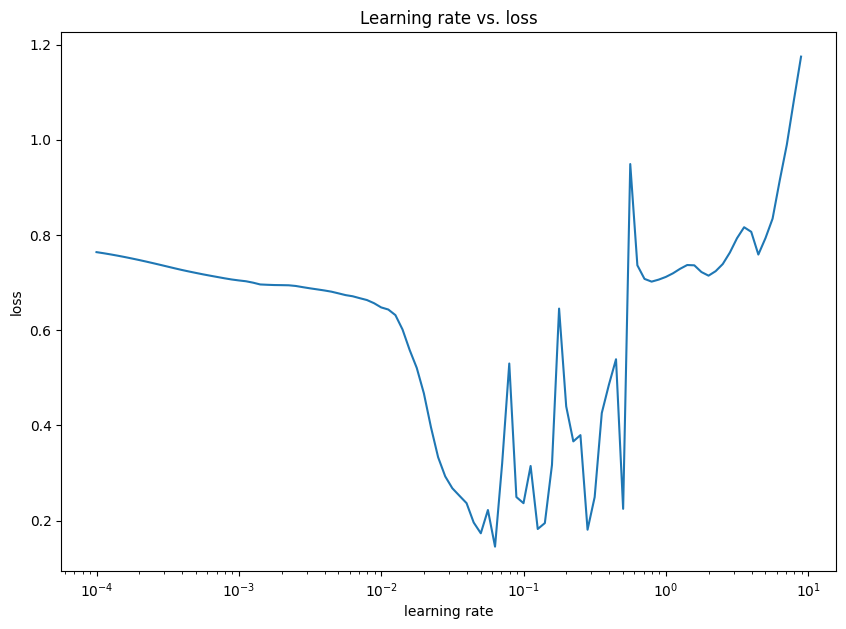

In [37]:
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_9.history['loss'])
plt.xlabel('learning rate')
plt.ylabel('loss')
plt.title('Learning rate vs. loss')

Best lr is 10x the lowest point on the graph, where the loss is still decreasing exponentially

In [38]:
# Tryig to use a higher ideal learning rate

tf.random.set_seed(42)

model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model_10.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics=['accuracy']
)

history_10 = model_10.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5050 - loss: 0.6931
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5375 - loss: 0.6872
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5462 - loss: 0.6785
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6675
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5987 - loss: 0.6560
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6212 - loss: 0.6417
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6625 - loss: 0.6125
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7763 - loss: 0.5186
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8225 - loss: 0.4362
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8687 - loss: 0.3563
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9075 - loss: 0.2986 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9300 - l

In [39]:
model_10.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.1460  


[0.14602452516555786, 0.949999988079071]

In [40]:
model_8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0236 


[0.023561131209135056, 1.0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


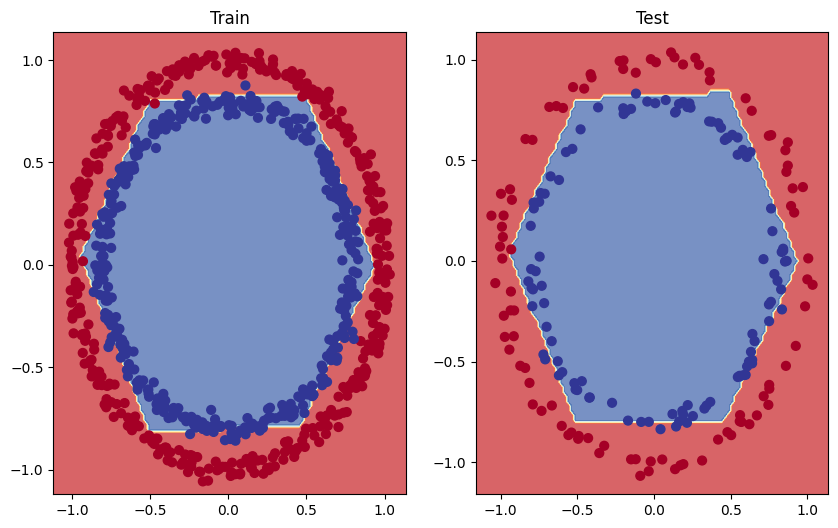

In [41]:
# Plot the decision boundary for model_19

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_10, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_10, X_test, y_test)

## Classification evaluation metrics

- Accuracy
- Precision
- Recall
- F1 - Score
- Confusion Matrix
- Classification Report

In [42]:
# Check the accuracy of our model
loss, accuracy = model_10.evaluate(X_test, y_test)
print(f'Model Loss: {(loss):.4f}')
print(f'Accuracy : {(accuracy):.3f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.1460 
Model Loss: 0.1460
Accuracy : 0.950


Confusion Matrix

In [43]:
from sklearn.metrics import confusion_matrix

# make predictions
y_preds = model_10.predict(X_test)

# predictions are in prediction probability form
# pred probs -> 1s and 0s

# Confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[93,  1],
       [ 9, 97]])

How about we prettify our confusion matrix?

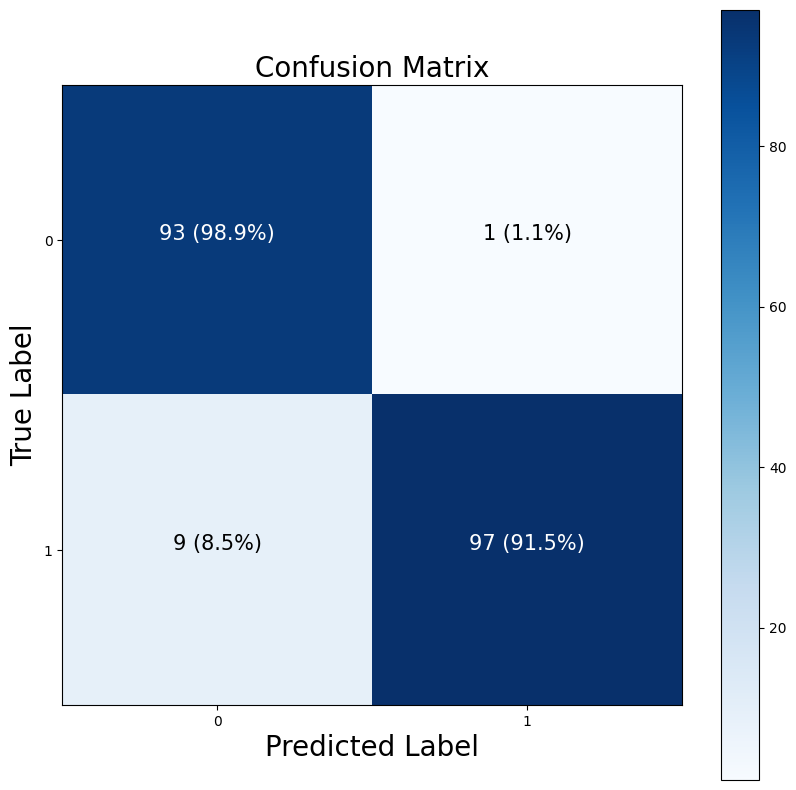

In [44]:
import itertools

figsize = (10, 10)

# Create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_normalize = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
n_classes = cm.shape[0]

# Visualization
fig, ax = plt.subplots(figsize=figsize)
# Create matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classes
classes = False
if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

# Label the axes
ax.set(title='Confusion Matrix',
       xlabel='Predicted Label',
       ylabel='True Label',
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set axis labels to bottom
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)

# set threshiold for different colors
threshold = (cm.max() + cm.min()) / 2.0

# Plot the text on each cell
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f'{cm[i, j]} ({cm_normalize[i,j]*100:.1f}%)',
           horizontalalignment='center',
           color='white' if cm[i,j] > threshold else 'black',
           size = 15)

# Multi-Class classification

Fashion MNIST for multi-class classification

In [45]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets
(train_data, train_labels) , (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [46]:
# Visualize example
train_data[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [47]:
train_labels[0]

np.uint8(9)

In [48]:
train_data[0].shape, train_labels[0].shape

((28, 28), ())

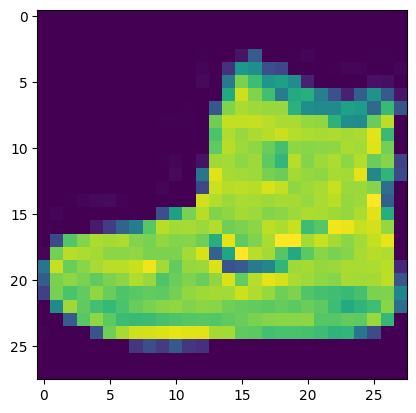

In [49]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[0])

In [50]:
# create list for labels : numbers -> names
class_names = ['top', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
len(class_names)

10

Text(0.5, 1.0, 'top')

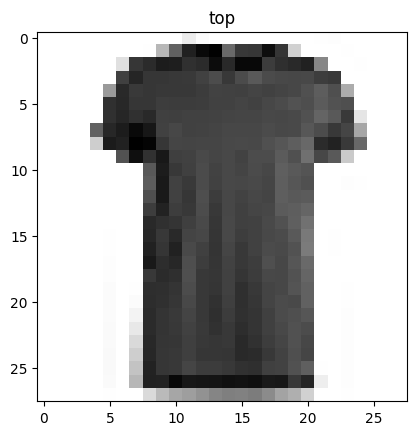

In [51]:
plt.imshow(train_data[17], cmap=plt.cm.binary)
plt.title(class_names[train_labels[17]])

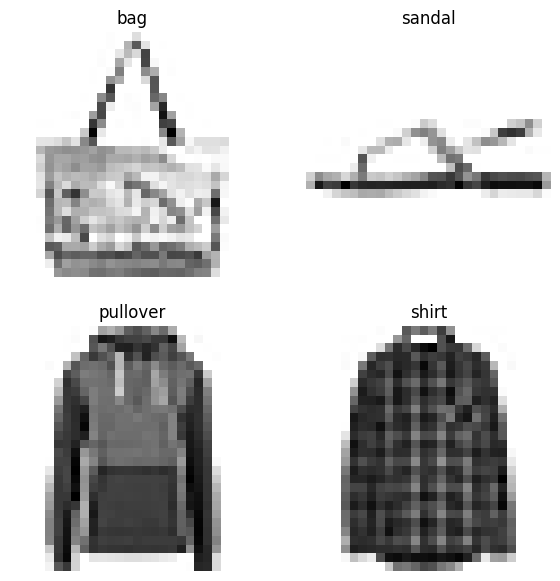

In [52]:
# plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7,7))
for i in range(4):
  ax = plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

## Build a multi-class classification model

Multi-class classification is simillar to binary classifiers but the input shape, final hidden layer shape, final layer activation changes:
- Input shape: 28x28
- Output Shape: 10
- Final layer activation: softmax
- Loss function: Categorical CrossEntropy (One-Hot Encoding) / Sparse Categorical Cross Entropy (Integers)

In [53]:
# Set random seed
tf.random.set_seed(42)

# create model
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

# Compile model
model_11.compile(
    loss=tf.keras.losses.CategoricalCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Fit the model
non_norm_history = model_11.fit(
    train_data,
    tf.one_hot(train_labels, depth=10),
    epochs=10,
    validation_data=(test_data, tf.one_hot(test_labels, depth=10))
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1737 - loss: 2.0700 - val_accuracy: 0.1976 - val_loss: 1.8269
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1953 - loss: 1.7655 - val_accuracy: 0.2003 - val_loss: 1.7314
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1988 - loss: 1.7139 - val_accuracy: 0.1999 - val_loss: 1.7027
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2000 - loss: 1.6959 - val_accuracy: 0.2005 - val_loss: 1.6971
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1985 - loss: 1.6901 - val_accuracy: 0.1996 - val_loss: 1.6920
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1988 - loss: 1.6852 - val_accuracy: 0.2000 - val_loss: 1.6866
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2004 - loss: 1.6821 - val_accuracy: 0.1988 - val_loss: 1.6901
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1995 - loss: 1.6797 - val_accura

In [54]:
model_11.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [55]:
# Min and Max
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Scaled inputs are always prefered for NN as inputs. Input constrained between 0 and 255

In [56]:
# We can get our training and testing data between 0 and 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

# check the train data's norm and mean
train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [57]:
# Now our data is normalized, build model

tf.random.set_seed(42)

model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model_12.compile(
    loss = tf.keras.losses.CategoricalCrossentropy,
    optimizer = tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

norm_history = model_12.fit(
    train_data_norm,
    tf.one_hot(train_labels, depth=10),
    epochs=10,
    validation_data=(test_data_norm, tf.one_hot(test_labels, depth=10))
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4853 - loss: 1.3378 - val_accuracy: 0.6688 - val_loss: 0.9337
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7094 - loss: 0.8231 - val_accuracy: 0.7294 - val_loss: 0.7757
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7470 - loss: 0.7290 - val_accuracy: 0.7479 - val_loss: 0.7235
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7598 - loss: 0.6864 - val_accuracy: 0.7564 - val_loss: 0.6975
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7695 - loss: 0.6584 - val_accuracy: 0.7658 - val_loss: 0.6804
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7787 - loss: 0.6393 - val_accuracy: 0.7698 - val_loss: 0.6683
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7835 - loss: 0.6256 - val_accuracy: 0.7758 - val_loss: 0.6609
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7870 - loss: 0.6151 - 

<Axes: title={'center': 'Non-Normalized Data'}>

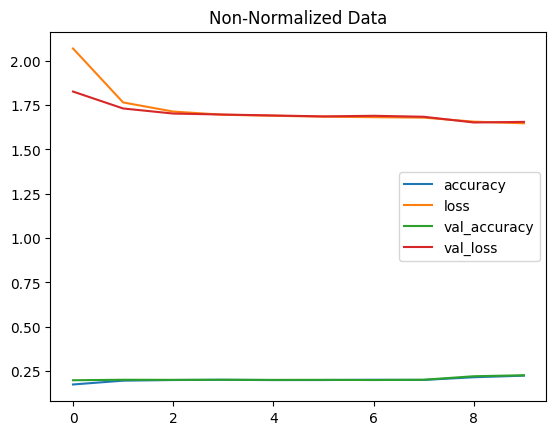

In [58]:
import pandas as pd

# Plot the non normalized data
pd.DataFrame(non_norm_history.history).plot(title='Non-Normalized Data')

<Axes: title={'center': 'Normalized Data'}>

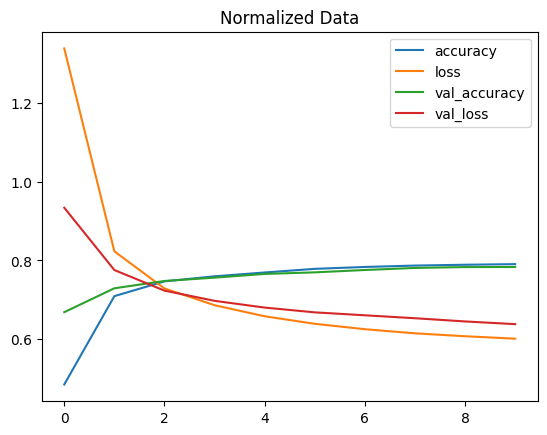

In [59]:
pd.DataFrame(norm_history.history).plot(title='Normalized Data')

Differently scaled data can vastly change the convergence curves

In [60]:
## Finding the Ideal learning rate

tf.random.set_seed(42)

model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model_13.compile(
    loss = 'categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

find_lr_history = model_13.fit(
    train_data_norm,
    tf.one_hot(train_labels, depth=10),
    epochs=40,
    callbacks=[lr_scheduler],
    validation_data=(test_data_norm, tf.one_hot(test_labels, depth=10))
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5391 - loss: 1.2519 - val_accuracy: 0.6670 - val_loss: 0.8808 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7159 - loss: 0.7810 - val_accuracy: 0.7402 - val_loss: 0.7337 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7517 - loss: 0.6884 - val_accuracy: 0.7532 - val_loss: 0.6820 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7589 - loss: 0.6554 - val_accuracy: 0.7566 - val_loss: 0.6620 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7618 - loss: 0.6390 - val_accuracy: 0.7585 - val_loss: 0.6502 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7642 - loss: 0.6289 - val_accuracy: 0.7592 - val_loss: 0.6427 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7659 - l

Text(0.5, 1.0, 'Idead Learning Rate')

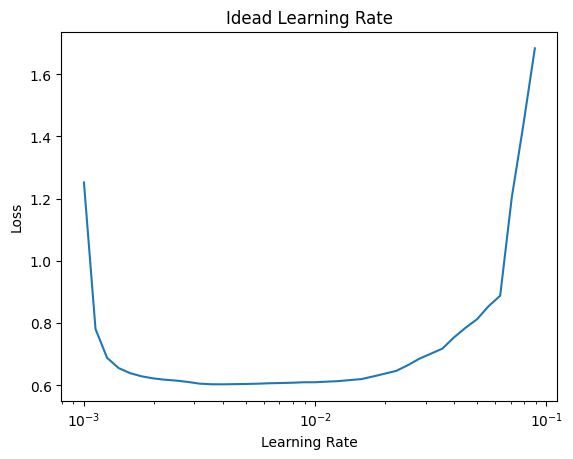

In [61]:
#Plot the learning rate decay curve
lrs = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs,find_lr_history.history['loss'])
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Idead Learning Rate')

In [62]:
# New model with best lr
tf.random.set_seed(42)

model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model_14.compile(
    loss=tf.keras.losses.CategoricalCrossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.09),
    metrics=['accuracy']
)

history_14 = model_14.fit(
    train_data_norm,
    tf.one_hot(train_labels, depth=10),
    epochs=20,
    callbacks=[lr_scheduler],
    validation_data=(test_data_norm, tf.one_hot(test_labels, depth=10))
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5287 - loss: 1.4325 - val_accuracy: 0.6845 - val_loss: 0.9304 - learning_rate: 0.0010
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7121 - loss: 0.7982 - val_accuracy: 0.7186 - val_loss: 0.7512 - learning_rate: 0.0011
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7498 - loss: 0.6921 - val_accuracy: 0.7846 - val_loss: 0.6519 - learning_rate: 0.0013
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7978 - loss: 0.6018 - val_accuracy: 0.8013 - val_loss: 0.5912 - learning_rate: 0.0014
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8092 - loss: 0.5614 - val_accuracy: 0.8064 - val_loss: 0.5682 - learning_rate: 0.0016
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8143 - loss: 0.5410 - val_accuracy: 0.8127 - val_loss: 0.5543 - learning_rate: 0.0018
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8173 - 

## Evaluating our multi-class classification model

To evaluate our multi-class classification model:
- Use confusion Matrix
- Visualize some predictions
- Improve resulsts by changing architecture/ trian longer
- Save and export it for use in an application

In [63]:
# Create a confusion matrix
import itertools
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true, y_preds, classes = None, figsize=(10,10), text_size=15):
  # Create the confusion matrix
  cm = confusion_matrix(y_true, tf.round(y_preds))
  cm_normalize = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
  n_classes = cm.shape[0]

  # Visualization
  fig, ax = plt.subplots(figsize=figsize)
  # Create matrix plot
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  # Create classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title='Confusion Matrix',
        xlabel='Predicted Label',
        ylabel='True Label',
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels)

  # Set axis labels to bottom
  ax.xaxis.set_label_position('bottom')
  ax.xaxis.tick_bottom()

  # Adjust label size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)

  # set threshiold for different colors
  threshold = (cm.max() + cm.min()) / 2.0

  # Plot the text on each cell
  for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f'{cm[i, j]} ({cm_normalize[i,j]*100:.1f}%)',
            horizontalalignment='center',
            color='white' if cm[i,j] > threshold else 'black',
            size = text_size)

In [64]:
class_names

['top',
 'trouser',
 'pullover',
 'dress',
 'coat',
 'sandal',
 'shirt',
 'sneaker',
 'bag',
 'ankle boot']

In [65]:
# Make predictions
y_probs = model_14.predict(test_data_norm) # prediction probabilities

# View first 5 probs
y_probs

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[8.7007135e-04, 3.3317558e-03, 2.8844324e-03, ..., 3.3323105e-02,
        1.5358895e-03, 6.6277355e-01],
       [6.4967563e-03, 3.7015064e-07, 8.3700192e-01, ..., 0.0000000e+00,
        7.6529503e-08, 1.4697112e-32],
       [6.0925954e-06, 9.9523234e-01, 5.1213311e-07, ..., 1.2583889e-23,
        8.9412160e-06, 5.3385778e-20],
       ...,
       [1.7204138e-02, 8.4542589e-06, 1.0246095e-03, ..., 5.3169634e-19,
        8.0696464e-01, 1.0252972e-19],
       [3.6158040e-06, 9.9446869e-01, 1.4154487e-07, ..., 1.1644472e-26,
        5.5561823e-06, 8.4305527e-23],
       [8.7231386e-04, 1.7688351e-05, 4.2068789e-04, ..., 3.1896856e-02,
        2.9678803e-02, 7.6601200e-04]], dtype=float32)

In [66]:
# Converting pred probs into class labels

y_preds = y_probs.argmax(axis=1)
y_preds[:10]

array([9, 2, 1, 1, 0, 1, 4, 6, 5, 7])

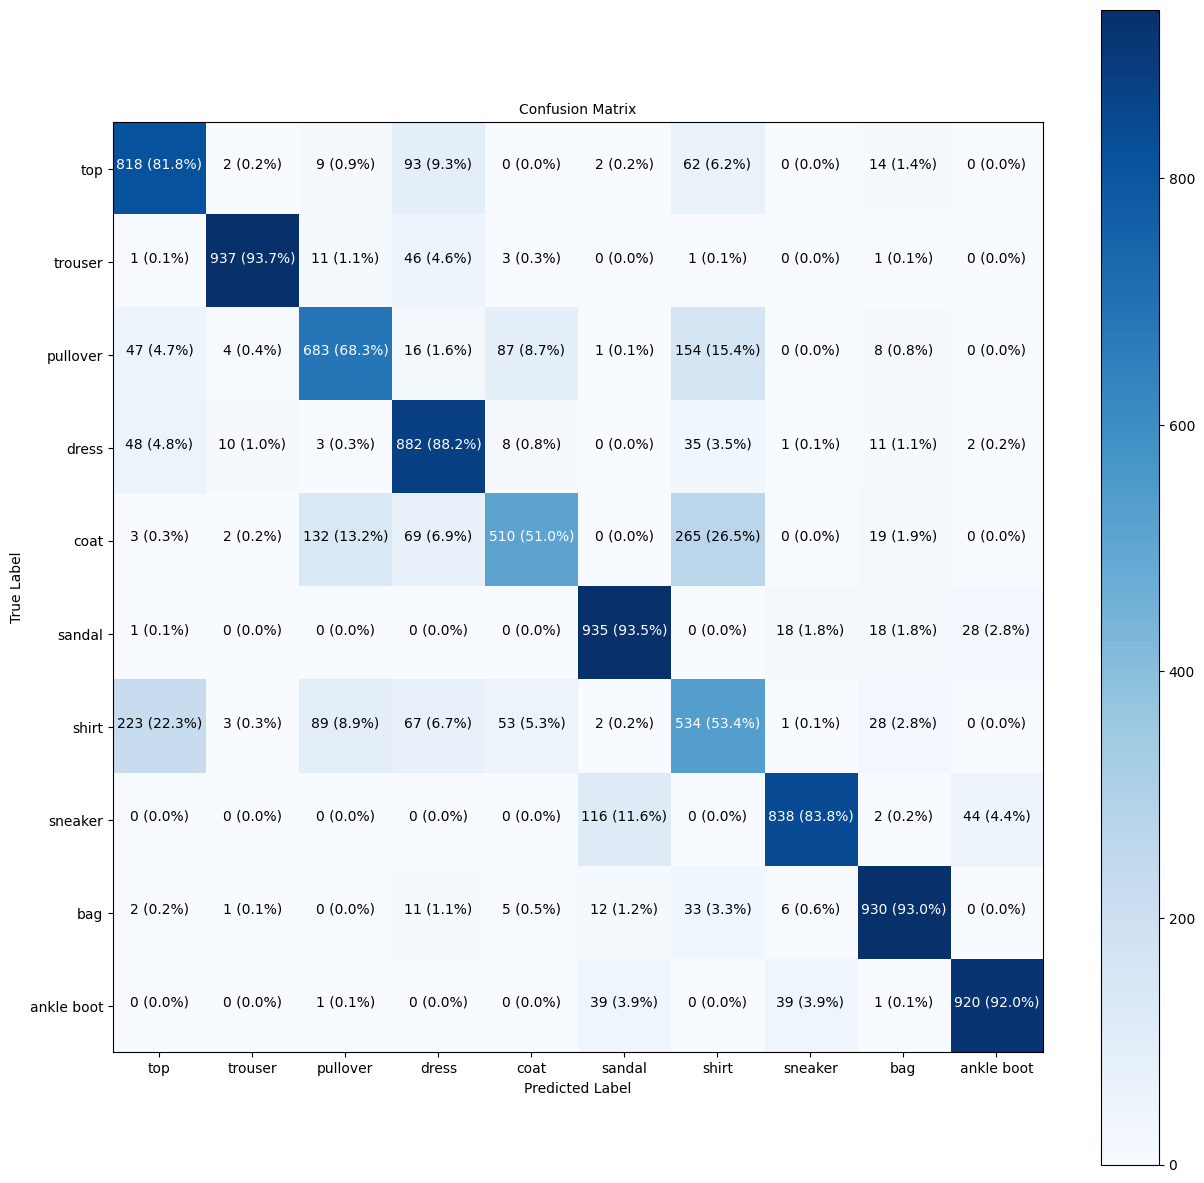

In [67]:
make_confusion_matrix(test_labels, y_preds, class_names, (15,15), 10)

In [68]:
from re import I
import random

def plot_random_image(model,
                      images,
                      true_labels,
                      classes):
  """
  Picks a random image, plots it and labels it with a prediction and truth label
  """

  # Set up random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1,28,28))
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  #Plot the image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is correct
  if pred_label == true_label:
    color = 'green'
  else:
    color = 'red'

  # Add xlabel information
  plt.xlabel('Pred: {} {:2.0f}% (True: {})'.format(pred_label, 100*tf.reduce_max(pred_probs), true_label), color=color) # SET THE COLOR TO G OR R

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


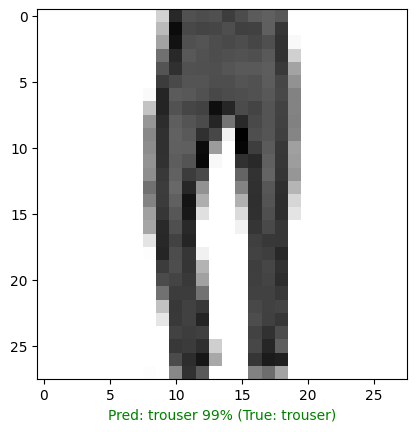

In [69]:
# Check out a random image
plot_random_image(
    model=model_14,
    images=test_data_norm,
    true_labels=test_labels,
    classes=class_names
)

## Patterns learned by models

In [70]:
model_14.layers

[<Flatten name=flatten_3, built=True>,
 <Dense name=dense_37, built=True>,
 <Dense name=dense_38, built=True>,
 <Dense name=dense_39, built=True>]

In [71]:
# Extract a particular layer
model_14.layers[1]

# Get patterns of a layer
weights, biases = model_14.layers[1].get_weights()

# Shapes
weights, weights.shape

(array([[-0.34610066,  3.4043458 ,  0.83666104, -2.96514   ],
        [-3.4440184 ,  4.2004895 ,  2.1087441 , -0.6453151 ],
        [-1.0617522 ,  3.4894278 , -0.57239574, -3.8078914 ],
        ...,
        [-2.6672668 ,  0.00798603, -0.9596439 ,  0.11033919],
        [-0.76971644, -1.1680559 ,  1.0464178 ,  0.80819595],
        [-1.370106  ,  0.5194378 ,  1.039216  , -0.10748853]],
       dtype=float32),
 (784, 4))

In [72]:
# Bias vector
biases, biases.shape

(array([ 4.015935  ,  3.3329375 ,  3.640129  , -0.40413788], dtype=float32),
 (4,))

Every nueron has a bias vector which is paired with a wight matrix.and
The bias vector gets initialized as a zero vector then is learned through back propagation

The bias vector dictates how much the patterns wihtin the corresponding weights matrix should influence the next layer

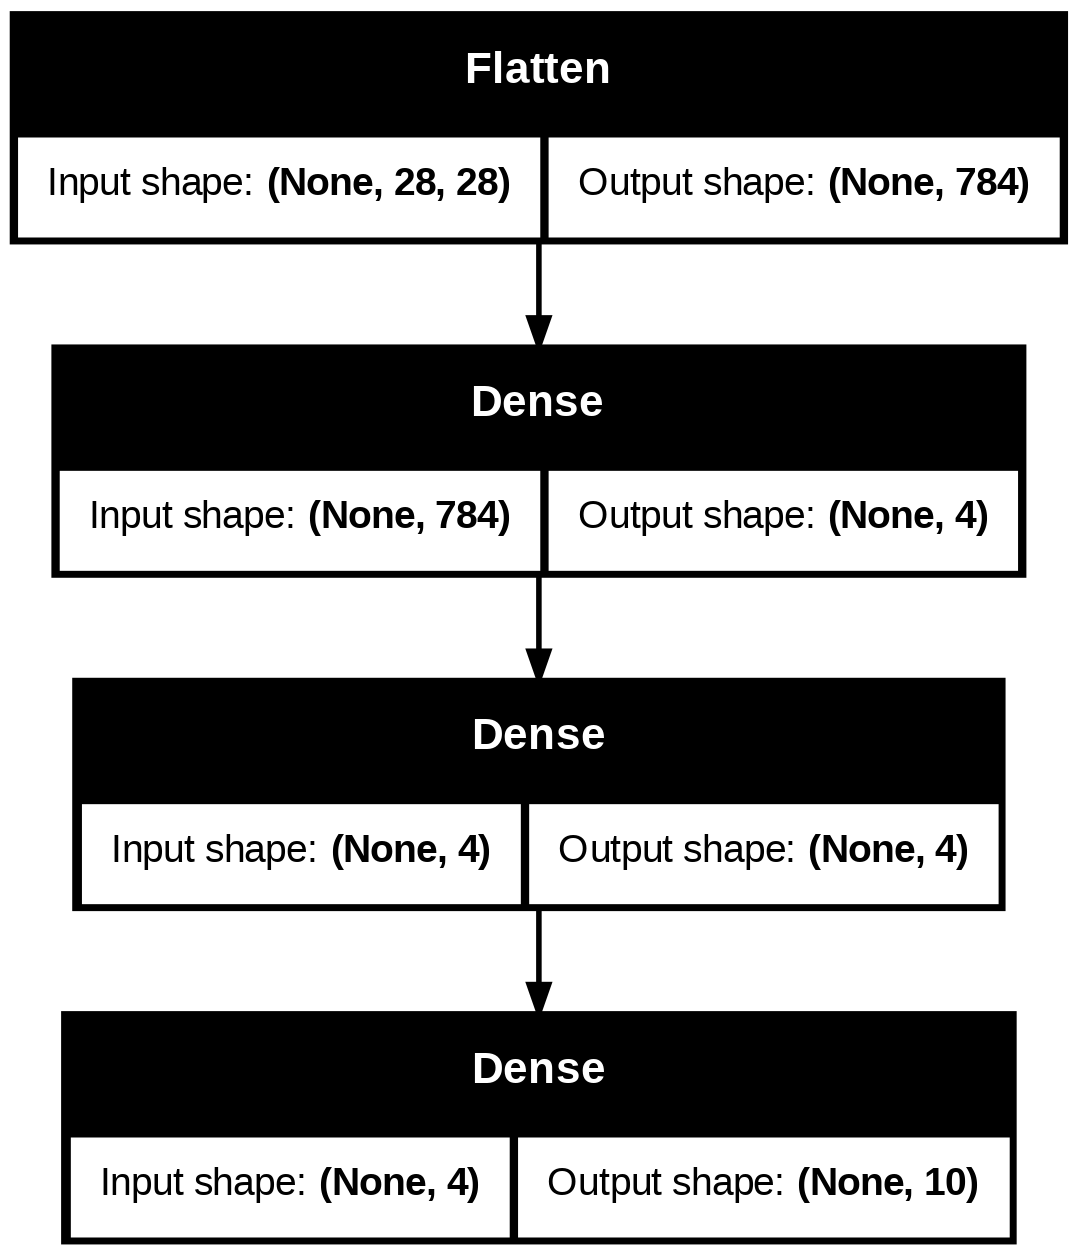

In [73]:
# More ways of viewing DL models
from tensorflow.keras.utils import plot_model

plot_model(model_14, show_shapes=True)

# Exercises

In [74]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.datasets import make_moons

moon_data, moon_labels = make_moons(1000, noise=0.05, random_state=42)

moon_data.shape, moon_labels.shape

((1000, 2), (1000,))

In [75]:
pd.DataFrame({'X0':moon_data[:,0],
             'X1':moon_data[:,1],
             'y':moon_labels})

,X0,X1,y
0,-0.021371,0.406186,1
1,0.976700,-0.458323,1
2,0.904059,-0.376520,1
3,0.377363,-0.397037,1
4,-0.841926,0.530587,0
...,...,...,...
995,0.798055,0.573064,0
996,-0.145492,0.952211,0
997,1.662585,-0.307919,1
998,-0.943559,0.327894,0


In [76]:
from sklearn.model_selection import train_test_split

moon_data_train, moon_data_test, moon_labels_train, moon_labels_test = train_test_split(
    moon_data,
    moon_labels,
    random_state=42,
    test_size=0.2
)

len(moon_data_train), len(moon_labels_test)

(800, 200)

In [77]:
moon_data_train.mean(), moon_data_train.std()

(np.float64(0.3704492097902331), np.float64(0.7218019677735737))

In [78]:
# Normalization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(moon_data_train)

moon_data_train_norm = scaler.transform(moon_data_train)
moon_data_test_norm = scaler.transform(moon_data_test)

In [79]:
moon_data_test_norm.shape, moon_data_train_norm.shape

((200, 2), (800, 2))

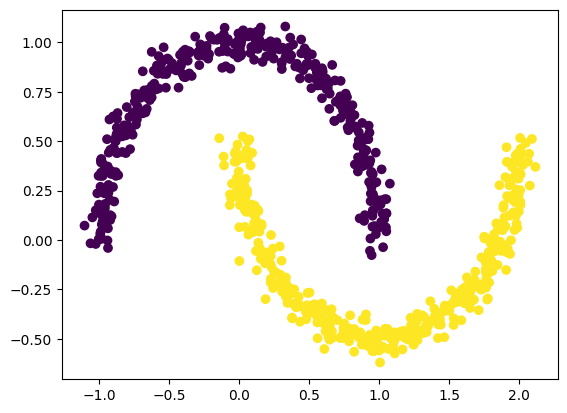

In [80]:
plt.scatter(moon_data_train[:, 0], moon_data_train[:, 1], c=moon_labels_train)

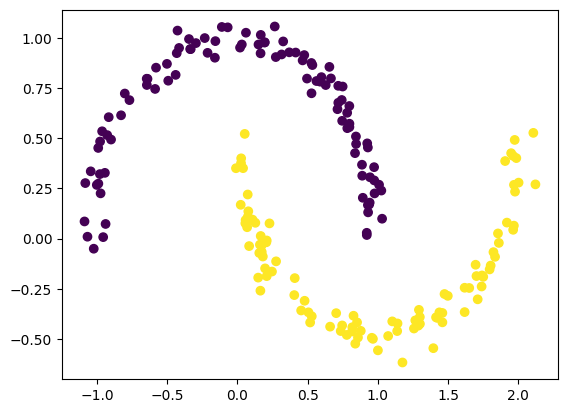

In [81]:
plt.scatter(moon_data_test[:, 0], moon_data_test[:, 1], c=moon_labels_test)

In [82]:
# Make model
tf.random.set_seed(42)

moon_model = tf.keras.Sequential([
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

moon_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer='Adam',
    metrics=['accuracy']
)

moon_model.fit(moon_data_train_norm, moon_labels_train, epochs=30)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7425 - loss: 0.6733
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.6330 
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8338 - loss: 0.5648 
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8512 - loss: 0.4715 
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8612 - loss: 0.3772 
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8775 - loss: 0.3099 
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9025 - loss: 0.2684 
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9025 - loss: 0.2449 
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9025 - loss: 0.2294 
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9038 - loss: 0.2165
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9075 - loss: 0.2048
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9

In [83]:
moon_model.evaluate(moon_data_test_norm, moon_labels_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0044  


[0.004350308794528246, 1.0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Binary Classification


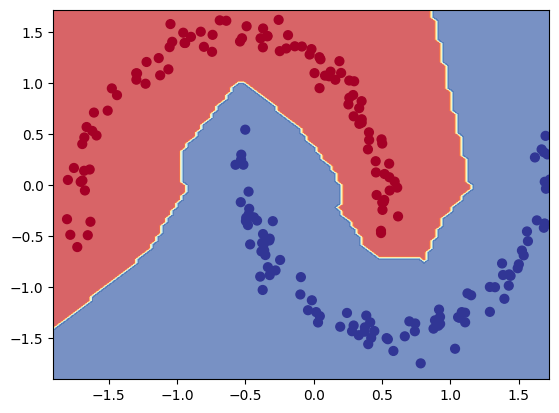

In [84]:
plot_decision_boundary(moon_model, moon_data_test_norm, moon_labels_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Binary Classification


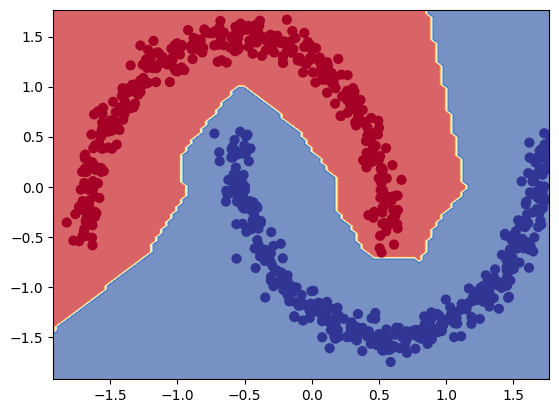

In [85]:
plot_decision_boundary(moon_model, moon_data_train_norm, moon_labels_train)

## Ex. 4 Fashion MNIST

In [86]:
from tensorflow.keras.datasets import fashion_mnist

(fashion_data_train, fashion_labels_train), (fashion_data_test, fashion_labels_test) = fashion_mnist.load_data()

In [87]:
fashion_data_train_norm = fashion_data_train / 255.0
fashion_data_test_norm = fashion_data_test / 255.0

In [88]:
# Model
tf.random.set_seed(42)

fashion_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

fashion_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy,
    optimizer='Adam',
    metrics=['accuracy']
)

fashion_model.fit(
    fashion_data_train_norm,
    tf.one_hot(fashion_labels_train, depth=10),
    epochs=20,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7920 - loss: 0.6250
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8587 - loss: 0.4022
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8710 - loss: 0.3601
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8793 - loss: 0.3335
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8869 - loss: 0.3135
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8912 - loss: 0.2975
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8952 - loss: 0.2848
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8996 - loss: 0.2726
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9036 - loss: 0.2630
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9068 - loss: 0.2533
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9102 - loss: 0.2455
Epoch 12/20
1875/1875 ━━━━━━

In [89]:
fashion_model.evaluate(fashion_data_test_norm, tf.one_hot(fashion_labels_test, depth=10))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8720 - loss: 0.4146


[0.414630264043808, 0.871999979019165]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


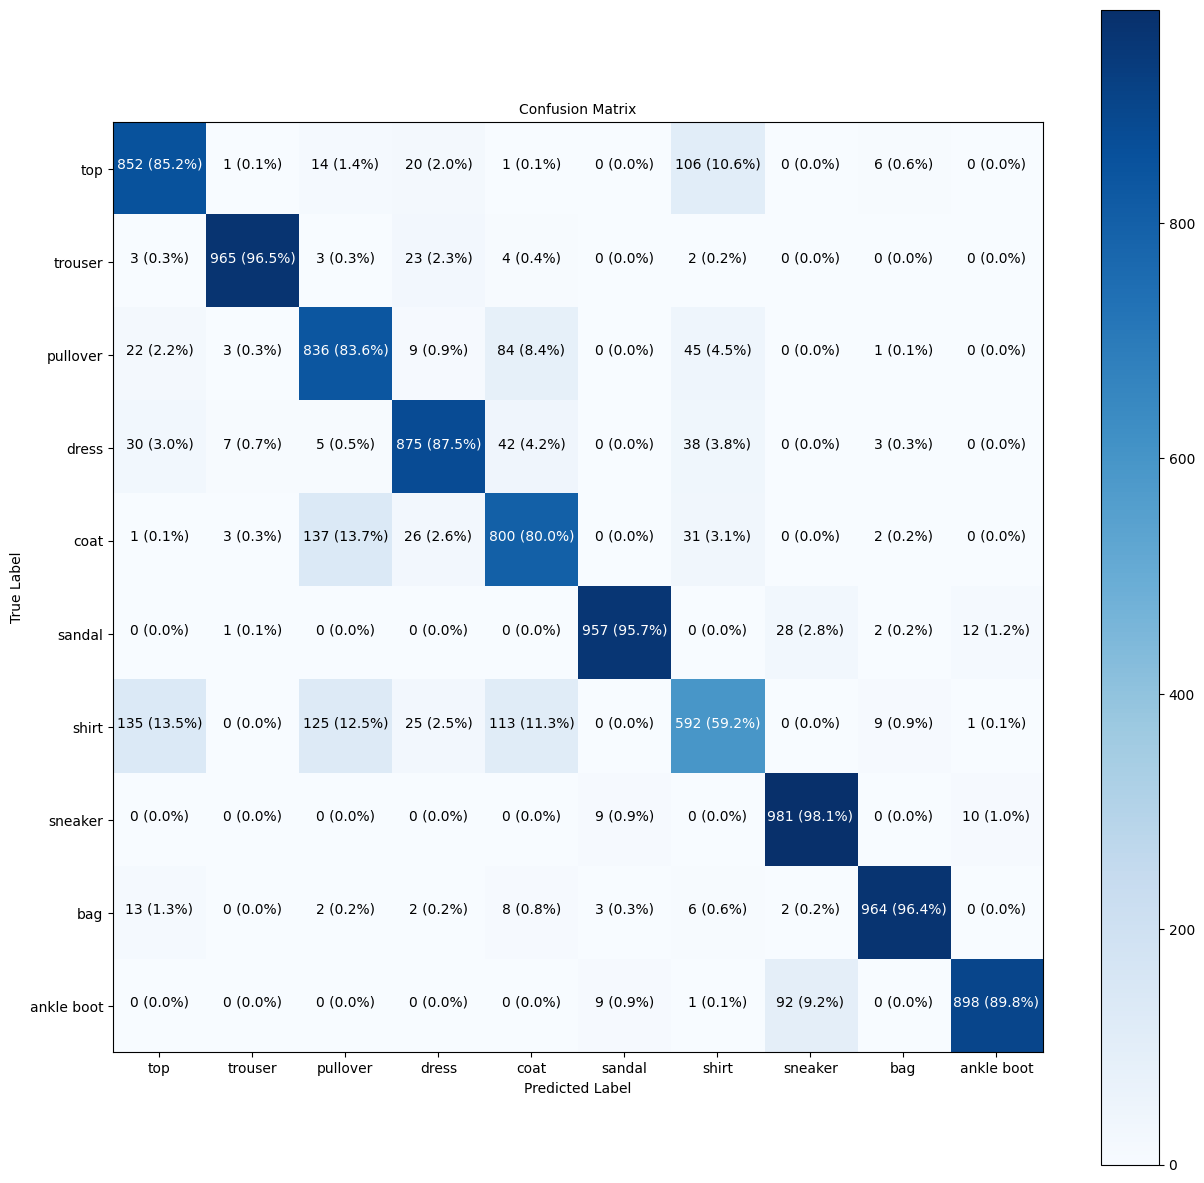

In [90]:
fashion_probs = fashion_model.predict(fashion_data_test_norm)
fashion_preds = fashion_probs.argmax(axis=1)

make_confusion_matrix(fashion_labels_test, fashion_preds, class_names, (15,15), 10)

In [94]:
# Recreate softmax function from tensor flow
def softmax(input: tf.Tensor):

  denom = sum([tf.math.exp(x) for x in input])

  output = [tf.math.exp(x)/ denom for x in input]
  return output

In [96]:
dummy = [2.50, 4.99, 1.0, 0.44, 2.8]
out = softmax(dummy)

In [97]:
out

[<tf.Tensor: shape=(), dtype=float32, numpy=0.06774280965328217>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.8170644640922546>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.015115463174879551>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.00863408949226141>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.09144322574138641>]

In [100]:
soft_from_tf = tf.keras.activations.softmax(tf.expand_dims(dummy,1), axis=0)
soft_from_tf

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[0.0677428 ],
       [0.81706446],
       [0.01511546],
       [0.00863409],
       [0.09144321]], dtype=float32)>

### Visualization exercise

In [101]:
class_label = 4
class_names[class_label]

'coat'

In [107]:
select_test_idx = [i for i,label in enumerate(fashion_labels_test) if label == class_label]

In [109]:
selected_test_data = [fashion_data_test_norm[i] for i in select_test_idx]

In [113]:
selected_test_data[0].shape

(28, 28)

In [122]:
fashion_model.predict(tf.expand_dims(selected_test_data[0],axis=0)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([4])

In [120]:
tf.expand_dims(selected_test_data[0],axis=0).shape

TensorShape([1, 28, 28])

In [119]:
fashion_data_test.shape

(10000, 28, 28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


/tmp/ipykernel_2759/1341148602.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  title = f'Label: {class_names[fashion_labels_test[chosen_idx]]}, Pred: {class_names[int(prediction.argmax(axis=1))]}'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


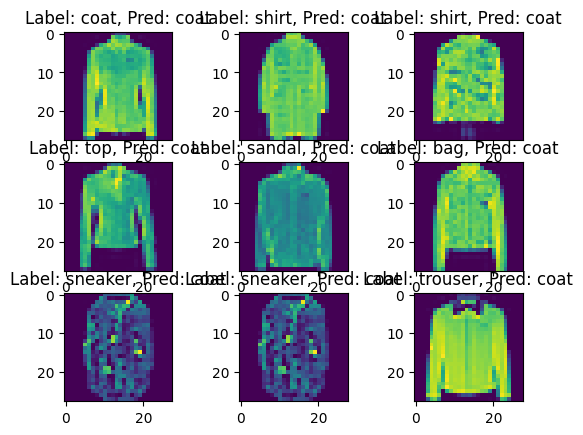

In [146]:
n=3

fig, ax = plt.subplots(nrows=n, ncols=n)
for i in range(n*n):
  chosen_idx = int(tf.keras.random.randint([1],0,len(selected_test_data)))
  prediction = fashion_model.predict(tf.expand_dims(selected_test_data[chosen_idx],axis=0))
  plt.subplot(n,n,i+1)
  plt.imshow(selected_test_data[chosen_idx])
  title = f'Label: {class_names[fashion_labels_test[chosen_idx]]}, Pred: {class_names[int(prediction.argmax(axis=1))]}'
  plt.title(title)

In [147]:
def display_class(label_name, test_labels, test_data, n, model, class_names):

  map = {name:idx for idx,name in enumerate(class_names)}
  label = map[label_name]
  select_test_idx = [i for i,label in enumerate(fashion_labels_test) if label == class_label]
  selected_test_data = [test_data[i] for i in select_test_idx]

  fig, ax = plt.subplots(nrows=n, ncols=n)
  for i in range(n*n):
    chosen_idx = int(tf.keras.random.randint([1],0,len(selected_test_data)))
    prediction = model.predict(tf.expand_dims(selected_test_data[chosen_idx],axis=0))
    plt.subplot(n,n,i+1)
    plt.imshow(selected_test_data[chosen_idx])
    title = f'Label: {class_names[test_labels[chosen_idx]]}, Pred: {class_names[int(prediction.argmax(axis=1))]}'
    plt.title(title)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


/tmp/ipykernel_2759/1543855181.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  title = f'Label: {class_names[test_labels[chosen_idx]]}, Pred: {class_names[int(prediction.argmax(axis=1))]}'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


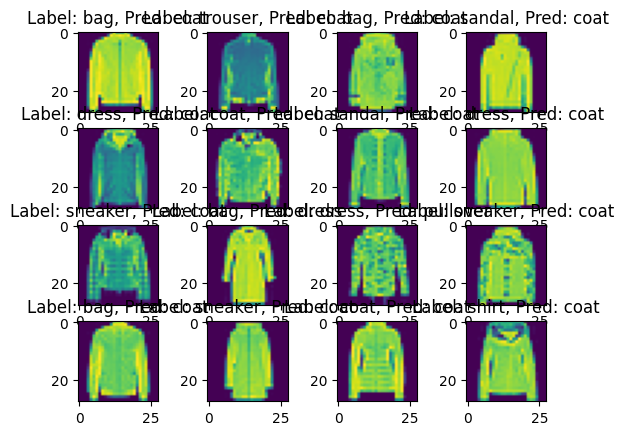

In [148]:
display_class('coat',
              fashion_labels_test,
              fashion_data_test_norm,
              4,
              fashion_model,
              class_names)